# Clinical Trials Analysis
## Data sourced live from ClinicalTrials.gov — Cancer trials, May 2026

This notebook analyses 20 cancer-related clinical trials. 
It explores trial phases, funding sources, and study status 
to identify patterns relevant to pharma AI strategy.

In [ ]:
# Import libraries we need
# requests: for fetching data from URLs
# pandas: for working with the data once we have it
import requests
import pandas as pd

# Empty list to collect all studies across multiple pages
all_studies = []

# Token that tells the API where the next page starts
# None to begin with because we're on the first page
next_token = None

# Loop up to 5 times — one iteration per page of 20 results
for page in range(5):
    
    # Build the API URL — asking for cancer trials in JSON format
    url = "https://clinicaltrials.gov/api/v2/studies?format=json&query.cond=cancer&pageSize=20"
    
    # From page 2 onwards, attach the token so the API knows which page we want
    if next_token:
        url += f"&pageToken={next_token}"
    
    # Fetch the URL — like typing it into a browser but in code
    response = requests.get(url)
    
    # Convert the raw response into a Python dictionary
    data = response.json()
    
    # Extract the list of studies from the response
    # If "studies" key doesn't exist, return an empty list instead of an error
    studies = data.get("studies", [])
    
    # Add this page's studies to our master list
    all_studies.extend(studies)
    
    # Get the token for the next page
    # If there isn't one, next_token becomes None and the loop stops
    next_token = data.get("nextPageToken")
    if not next_token:
        break

# How many studies did we collect across all pages?
print(f"Total studies fetched: {len(all_studies)}")
import matplotlib.pyplot as plt


Total studies fetched: 100


In [ ]:
# Convert the list of JSON study objects into a pandas DataFrame
# pd.json_normalize flattens nested JSON into columns
# We call it df_all to distinguish from df_clean (our filtered working dataset)
df_all = pd.json_normalize(all_studies)

# Check how many trials and fields we got
print(f"Rows (trials): {df_all.shape[0]}")
print(f"Columns (fields): {df_all.shape[1]}")


Rows (trials): 100
Columns (fields): 137
['hasResults', 'protocolSection.identificationModule.nctId', 'protocolSection.identificationModule.orgStudyIdInfo.id', 'protocolSection.identificationModule.organization.fullName', 'protocolSection.identificationModule.organization.class', 'protocolSection.identificationModule.briefTitle', 'protocolSection.identificationModule.officialTitle', 'protocolSection.statusModule.statusVerifiedDate', 'protocolSection.statusModule.overallStatus', 'protocolSection.statusModule.expandedAccessInfo.hasExpandedAccess', 'protocolSection.statusModule.startDateStruct.date', 'protocolSection.statusModule.startDateStruct.type', 'protocolSection.statusModule.primaryCompletionDateStruct.date', 'protocolSection.statusModule.primaryCompletionDateStruct.type', 'protocolSection.statusModule.completionDateStruct.date', 'protocolSection.statusModule.completionDateStruct.type', 'protocolSection.statusModule.studyFirstSubmitDate', 'protocolSection.statusModule.studyFirstSub

In [ ]:
# Select and rename all columns we need in one go
# This avoids multiple merges that create duplicate columns
df_clean = df_all[[
    "protocolSection.identificationModule.nctId",
    "protocolSection.identificationModule.briefTitle",
    "protocolSection.statusModule.overallStatus",
    "protocolSection.designModule.phases",
    "protocolSection.designModule.enrollmentInfo.count",
    "protocolSection.sponsorCollaboratorsModule.leadSponsor.class",
    "protocolSection.conditionsModule.conditions",
    "protocolSection.statusModule.startDateStruct.date",
    "protocolSection.statusModule.completionDateStruct.date",
    "protocolSection.statusModule.primaryCompletionDateStruct.date"
]].rename(columns={
    "protocolSection.identificationModule.nctId": "trial_id",
    "protocolSection.identificationModule.briefTitle": "title",
    "protocolSection.statusModule.overallStatus": "status",
    "protocolSection.designModule.phases": "phases",
    "protocolSection.designModule.enrollmentInfo.count": "enrollment",
    "protocolSection.sponsorCollaboratorsModule.leadSponsor.class": "funder_type",
    "protocolSection.conditionsModule.conditions": "conditions",
    "protocolSection.statusModule.startDateStruct.date": "start_date",
    "protocolSection.statusModule.completionDateStruct.date": "completion_date",
    "protocolSection.statusModule.primaryCompletionDateStruct.date": "primary_completion_date"
})

# Convert date columns to datetime format
# Using format='mixed' because some dates are "2005-05" and others are "2005-05-01"
df_clean["start_date"] = pd.to_datetime(df_clean["start_date"], format="mixed")
df_clean["completion_date"] = pd.to_datetime(df_clean["completion_date"], format="mixed")
df_clean["primary_completion_date"] = pd.to_datetime(df_clean["primary_completion_date"], format="mixed")

print(df_clean.shape)
df_clean.head()

(100, 10)


,trial_id,title,status,phases,enrollment,funder_type,conditions,start_date,completion_date,primary_completion_date
0,NCT01034787,Study of AntiCTLA4 in Patients With Unresectab...,COMPLETED,[PHASE2],11.0,OTHER,[Uveal Melanoma],2009-08-17,2017-08-08,2017-08-08
1,NCT02583893,Biomarkers in Predicting Treatment Response to...,COMPLETED,[PHASE2],39.0,OTHER,"[Recurrent Adult Acute Myeloid Leukemia, Secon...",2015-10-07,2023-05-17,2023-04-17
2,NCT00208793,Calcium and Vitamin D vs Markers of Adenomatou...,COMPLETED,[PHASE2],92.0,OTHER,[Colorectal Adenomatous Polyps],2005-05-01,2013-02-01,2006-09-01
3,NCT01949714,Effect of Chronic Catecholamine Overproduction...,COMPLETED,NaN,10.0,OTHER,"[Pheochromocytoma, Adrenal Incidentaloma]",2013-08-01,2022-01-01,2022-01-01
4,NCT04566614,Preventing Viral Pandemic Associated Risk of C...,COMPLETED,NaN,128.0,OTHER,"[Neoplasm, Colorectal, Neoplasm of Lung, Neopl...",2020-06-18,2025-01-31,2023-07-31


In [ ]:
# ── DATA CLEANING ──────────────────────────────────────────────────
# Apply all filters in one place so the rest of the notebook is clean

# Step 1: Convert phases lists to plain strings
# The API returns phases as lists like ["PHASE2"] — convert to "PHASE2"
df_clean["phases_clean"] = df_clean["phases"].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else "UNKNOWN"
)

# Step 2: Remove observational studies (no phase by design)
# and interventional trials with no phase recorded
df_clean = df_clean[df_clean["phases_clean"] != "UNKNOWN"]
df_clean = df_clean[df_clean["phases_clean"] != "NA"]
df_clean = df_clean[df_clean["phases_clean"].notna()]

# Step 3: Remove trials with missing enrollment data
df_clean = df_clean[df_clean["enrollment"].notna()]

# Step 4: Remove withdrawn trials with 0 enrollment
df_clean = df_clean[df_clean["enrollment"] > 0]

# Summary of what we kept
print(f"Trials after cleaning: {len(df_clean)}")
print(f"Phases: {df_clean['phases_clean'].value_counts().to_dict()}")


In [ ]:
# Check what's actually in df_clean
df_clean["status"].value_counts()

status
COMPLETED                46
RECRUITING               17
NOT_YET_RECRUITING       10
UNKNOWN                  10
TERMINATED                6
ACTIVE_NOT_RECRUITING     6
WITHDRAWN                 4
SUSPENDED                 1
Name: count, dtype: int64

In [5]:
# Count how many trials fall into each status category
# e.g. Completed, Recruiting, Terminated
# Then display as a bar chart
df_clean["status"].value_counts().plot(
    kind="bar",                           # Vertical bar chart
    title="Clinical Trials by Status",
    color="steelblue",                    # A muted blue — easy on the eyes
    figsize=(10, 5)                       # Wide and not too tall
)

# Label the axes
plt.xlabel("Status")
plt.ylabel("Number of Trials")

# Rotate x-axis labels so they don't overlap each other
plt.xticks(rotation=45)

# Prevent labels being cut off at the edges
plt.tight_layout()

# Display the chart
plt.show()


NameError: name 'df_clean' is not defined

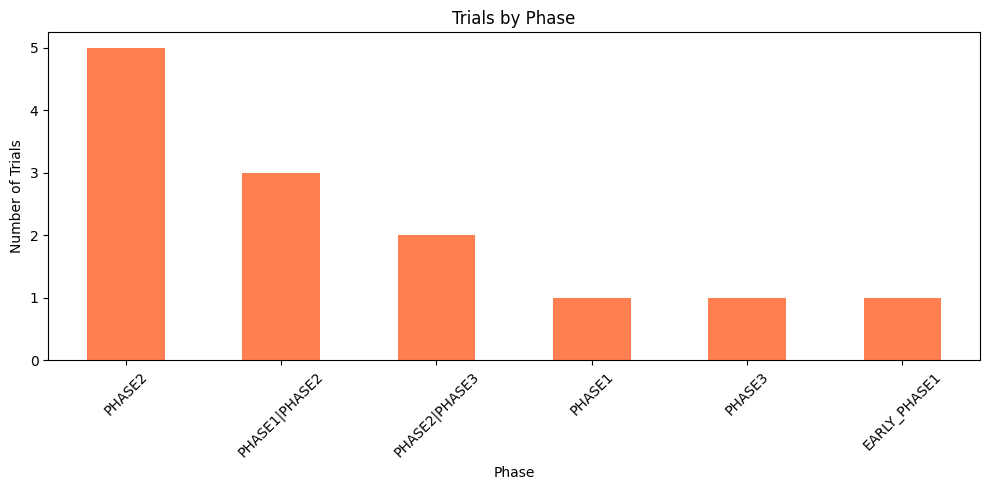

In [ ]:
# Count how many trials are in each phase
# Phases range from Early Phase 1 through Phase 3
# Combined phases like Phase 2/3 are also possible — seamless trials
# Note: phases_clean is used here as it contains cleaned string values
# (the raw phases column contains lists)
df_clean["phases"].astype(str).value_counts().plot(
    kind="bar",
    title="Trials by Phase",
    color="coral",                        # Warm colour to distinguish from the Status chart
    figsize=(10, 5)
)

# Label the axes
plt.xlabel("Phase")
plt.ylabel("Number of Trials")

# Rotate x-axis labels so they don't overlap
plt.xticks(rotation=45)

# Prevent labels being cut off at the edges
plt.tight_layout()

# Display the chart
plt.show()


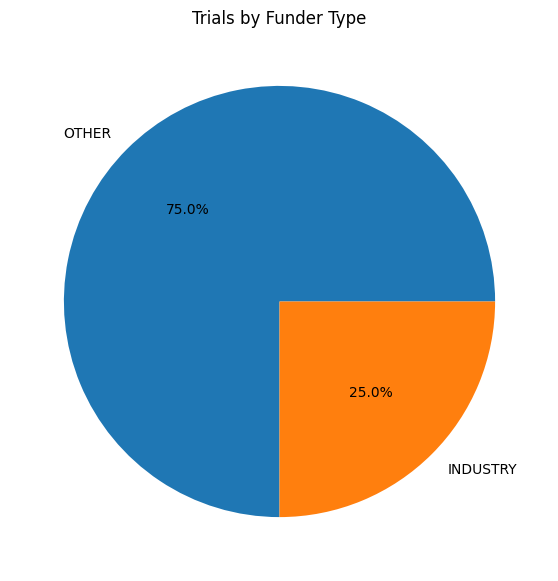

In [ ]:
# Count how many trials each funder type is responsible for
# Then display as a pie chart to show proportional breakdown
df_clean["funder_type"].value_counts().plot(
    kind="pie",           # Pie chart — good for showing proportions that add up to 100%
    title="Trials by Funder Type",
    figsize=(7, 7),       # Square dimensions work best for pie charts
    autopct="%1.1f%%"     # Show percentage on each slice, rounded to 1 decimal place
                          # "%1.1f%%" means: at least 1 digit, 1 decimal place, % sign
)

# Remove the default y-axis label which just says "Funder Type" — unnecessary on a pie chart
plt.ylabel("")

# Display the chart
plt.show()

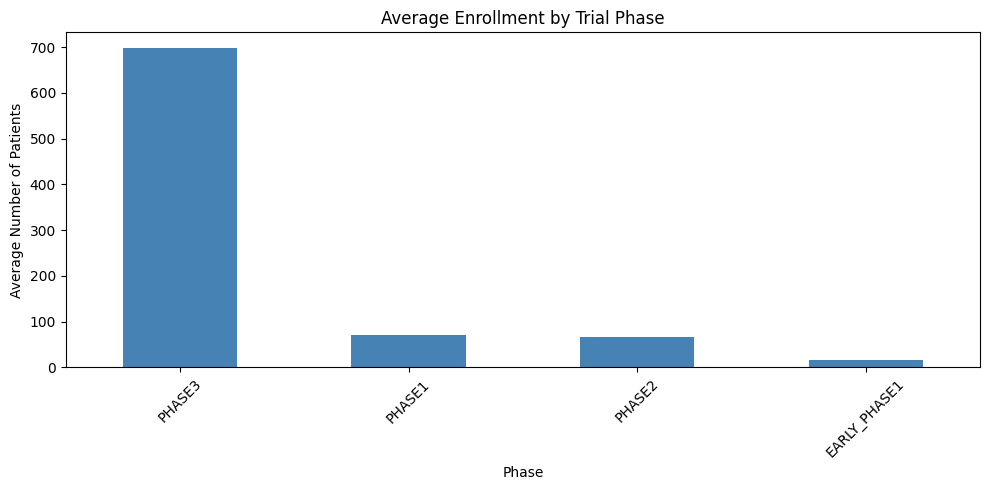

In [ ]:
# Average enrollment by trial phase
# phases_clean already created in the data cleaning step above
df_clean.groupby("phases_clean")["enrollment"].mean().sort_values(ascending=False).plot(
    kind="bar",
    title="Average Enrollment by Trial Phase",
    color="steelblue",
    figsize=(10, 5)
)

plt.xlabel("Phase")
plt.ylabel("Average Number of Patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# How many trials did we lose through filtering?
total_original = 100
total_remaining = len(df_clean)
total_excluded = total_original - total_remaining

print(f"Original dataset:  {total_original} trials")
print(f"After filtering:   {total_remaining} trials")
print(f"Excluded:          {total_excluded} trials ({total_excluded}%)")
print()

# What study types are in our remaining clean dataset?
# This tells us whether we're now comparing like with like
print("Study types in filtered dataset:")
print(df_clean["phases_clean"].value_counts())

Original dataset:  100 trials
After filtering:   55 trials
Excluded:          45 trials (45%)

Study types in filtered dataset:
phases_clean
PHASE1          24
PHASE2          20
PHASE3           9
EARLY_PHASE1     2
Name: count, dtype: int64


In [ ]:
# Create a dataframe of ALL 100 trials with just the fields we need to investigate
df_all = pd.json_normalize(all_studies)

# Get the study type and phases columns for all trials
df_investigation = df_all[[
    "protocolSection.identificationModule.nctId",
    "protocolSection.designModule.studyType",
    "protocolSection.designModule.phases"
]].rename(columns={
    "protocolSection.identificationModule.nctId": "trial_id",
    "protocolSection.designModule.studyType": "study_type",
    "protocolSection.designModule.phases": "phases"
})

# Show trials where phases is empty or NA
df_no_phase = df_investigation[
    df_investigation["phases"].isna() | 
    (df_investigation["phases"].astype(str).isin(["nan", "[]", "NA"]))
]

print(f"Trials with no phase: {len(df_no_phase)}")
print()
print("Study types of excluded trials:")
print(df_no_phase["study_type"].value_counts())

Trials with no phase: 24

Study types of excluded trials:
study_type
OBSERVATIONAL    24
Name: count, dtype: int64


In [ ]:
# Investigate trials with missing enrollment data
# Start from df_all which has all 100 trials
df_investigation2 = df_all[[
    "protocolSection.identificationModule.nctId",
    "protocolSection.designModule.studyType",
    "protocolSection.designModule.phases",
    "protocolSection.statusModule.overallStatus",
    "protocolSection.designModule.enrollmentInfo.count"
]].rename(columns={
    "protocolSection.identificationModule.nctId": "trial_id",
    "protocolSection.designModule.studyType": "study_type",
    "protocolSection.designModule.phases": "phases",
    "protocolSection.statusModule.overallStatus": "status",
    "protocolSection.designModule.enrollmentInfo.count": "enrollment"
})

# Filter to trials that have a phase but no enrollment number
df_no_enrollment = df_investigation2[
    df_investigation2["phases"].notna() &
    (df_investigation2["phases"].astype(str) != "[]") &
    df_investigation2["enrollment"].isna()
]

print(f"Trials with phase but no enrollment: {len(df_no_enrollment)}")
print()
print("Study status of these trials:")
print(df_no_enrollment["status"].value_counts())
print()
print("Phases of these trials:")
print(df_no_enrollment["phases"].value_counts())

Trials with phase but no enrollment: 1

Study status of these trials:
status
COMPLETED    1
Name: count, dtype: int64

Phases of these trials:
phases
[NA]    1
Name: count, dtype: int64


In [ ]:
# Account for all 45 excluded trials
print("Full exclusion breakdown:")
print(f"Observational studies (no phase):     24")
print(f"Missing enrollment data:               1")
print(f"Accounted for:                        25")
print(f"Still unexplained:                    {45 - 25}")
print()

# Check what's in df_clean vs the original 100
# Find trials that were excluded for other reasons
df_all_ids = set(df_investigation["trial_id"])
df_clean_ids = set(df_clean["trial_id"])
df_missing_ids = df_all_ids - df_clean_ids

print(f"Total excluded trial IDs: {len(df_missing_ids)}")

Full exclusion breakdown:
Observational studies (no phase):     24
Missing enrollment data:               1
Accounted for:                        25
Still unexplained:                    20

Total excluded trial IDs: 45


In [ ]:
# Get the full details of the 45 excluded trials
df_excluded_details = df_investigation2[
    df_investigation2["trial_id"].isin(df_missing_ids)
]

print("Status of all excluded trials:")
print(df_excluded_details["status"].value_counts())
print()
print("Study types of all excluded trials:")
print(df_excluded_details["study_type"].value_counts())
print()
print("Phases of all excluded trials:")
print(df_excluded_details["phases"].astype(str).value_counts())

Status of all excluded trials:
status
COMPLETED                21
RECRUITING                8
UNKNOWN                   6
NOT_YET_RECRUITING        5
TERMINATED                3
WITHDRAWN                 1
ACTIVE_NOT_RECRUITING     1
Name: count, dtype: int64

Study types of all excluded trials:
study_type
OBSERVATIONAL     24
INTERVENTIONAL    21
Name: count, dtype: int64

Phases of all excluded trials:
phases
['NA']    21
Name: count, dtype: int64


In [ ]:
# Print the actual average enrollment numbers per phase
# So we can quote specific figures in the README
print("Average enrollment by phase:")
print(df_clean.groupby("phases_clean")["enrollment"].mean().sort_values(ascending=False).round(0))
print()
print("Number of trials per phase:")
print(df_clean["phases_clean"].value_counts())

Average enrollment by phase:
phases_clean
PHASE3          697.0
PHASE1           72.0
PHASE2           66.0
EARLY_PHASE1     17.0
Name: enrollment, dtype: float64

Number of trials per phase:
phases_clean
PHASE1          24
PHASE2          20
PHASE3           9
EARLY_PHASE1     2
Name: count, dtype: int64


In [ ]:
# Check if one outlier is skewing the Phase 3 average
# Show all Phase 3 trials and their enrollment numbers
df_clean[df_clean["phases_clean"] == "PHASE3"][["title", "enrollment"]].sort_values(
    "enrollment", ascending=False
)

,title,enrollment
32,The HeLiX (Hemorrhage During Liver Resection: ...,1386.0
87,Safety and Efficacy of Pembrolizumab (MK-3475)...,959.0
50,Sunitinib Plus Prednisone In Patients With Met...,873.0
83,Safety and Efficacy of Talactoferrin in Previo...,742.0
27,A Study of Nilotinib Versus Imatinib in GIST P...,644.0
79,A Study of AK104 in Subjects With Unresectable...,560.0
22,Study of BTK Inhibitor LOXO-305 Versus Approve...,500.0
34,Guselkumab in Active Psoriatic Arthritis Parti...,453.0
94,Investigating the Potential Role of a Novel Qu...,160.0


In [ ]:
# Compare mean vs median for Phase 3 enrollment
# Mean is sensitive to outliers, median is more robust
phase3 = df_clean[df_clean["phases_clean"] == "PHASE3"]["enrollment"]

print(f"Phase 3 mean enrollment:   {phase3.mean():.0f}")
print(f"Phase 3 median enrollment: {phase3.median():.0f}")
print(f"Phase 3 min enrollment:    {phase3.min():.0f}")
print(f"Phase 3 max enrollment:    {phase3.max():.0f}")

Phase 3 mean enrollment:   697
Phase 3 median enrollment: 644
Phase 3 min enrollment:    160
Phase 3 max enrollment:    1386


In [ ]:
# Compare mean vs median across all phases
# This gives us a more complete picture of enrollment distributions
for phase in ["PHASE1", "PHASE2", "PHASE3", "EARLY_PHASE1"]:
    data = df_clean[df_clean["phases_clean"] == phase]["enrollment"]
    print(f"{phase}:")
    print(f"  Mean:   {data.mean():.0f}")
    print(f"  Median: {data.median():.0f}")
    print(f"  Min:    {data.min():.0f}")
    print(f"  Max:    {data.max():.0f}")
    print()

PHASE1:
  Mean:   72
  Median: 24
  Min:    0
  Max:    416

PHASE2:
  Mean:   66
  Median: 47
  Min:    0
  Max:    175

PHASE3:
  Mean:   697
  Median: 644
  Min:    160
  Max:    1386

EARLY_PHASE1:
  Mean:   17
  Median: 17
  Min:    14
  Max:    20



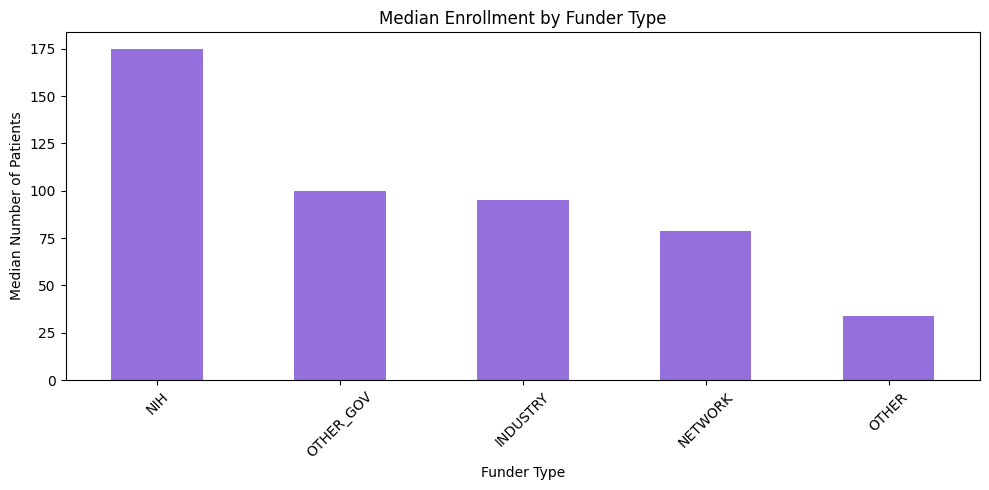

In [ ]:
# Do industry-funded trials enroll more patients than academic ones?
# This has real implications for AI-assisted trial design investment
df_clean.groupby("funder_type")["enrollment"].median().sort_values(ascending=False).plot(
    kind="bar",
    title="Median Enrollment by Funder Type",
    color="mediumpurple",
    figsize=(10, 5)
)

plt.xlabel("Funder Type")
plt.ylabel("Median Number of Patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Add sample sizes to the chart interpretation
print("Sample sizes per funder type:")
print(df_clean["funder_type"].value_counts())

Sample sizes per funder type:
funder_type
OTHER        27
INDUSTRY     21
NETWORK       2
OTHER_GOV     1
NIH           1
Name: count, dtype: int64


In [ ]:
# Check what date-related columns exist in our full dataset
date_cols = [col for col in df_all.columns if "date" in col.lower()]
print("Available date columns:")
for col in date_cols:
    print(f"  {col}")

Available date columns:
  protocolSection.statusModule.statusVerifiedDate
  protocolSection.statusModule.startDateStruct.date
  protocolSection.statusModule.startDateStruct.type
  protocolSection.statusModule.primaryCompletionDateStruct.date
  protocolSection.statusModule.primaryCompletionDateStruct.type
  protocolSection.statusModule.completionDateStruct.date
  protocolSection.statusModule.completionDateStruct.type
  protocolSection.statusModule.studyFirstSubmitDate
  protocolSection.statusModule.studyFirstSubmitQcDate
  protocolSection.statusModule.studyFirstPostDateStruct.date
  protocolSection.statusModule.studyFirstPostDateStruct.type
  protocolSection.statusModule.lastUpdateSubmitDate
  protocolSection.statusModule.lastUpdatePostDateStruct.date
  protocolSection.statusModule.lastUpdatePostDateStruct.type
  protocolSection.statusModule.resultsFirstSubmitDate
  protocolSection.statusModule.resultsFirstSubmitQcDate
  protocolSection.statusModule.resultsFirstPostDateStruct.date
  pro

In [6]:
# Calculate trial duration using both date types
# Primary duration = start to primary completion (core science done)
# Overall duration = start to full completion (all follow-up complete)

df_clean["primary_duration_months"] = (
    (df_clean["primary_completion_date"] - df_clean["start_date"]).dt.days / 30.44
).round(1)

df_clean["overall_duration_months"] = (
    (df_clean["completion_date"] - df_clean["start_date"]).dt.days / 30.44
).round(1)

# Compare the two
print("PRIMARY completion duration:")
print(f"  Mean:   {df_clean['primary_duration_months'].mean():.1f} months")
print(f"  Median: {df_clean['primary_duration_months'].median():.1f} months")
print(f"  Min:    {df_clean['primary_duration_months'].min():.1f} months")
print(f"  Max:    {df_clean['primary_duration_months'].max():.1f} months")
print()
print("OVERALL completion duration:")
print(f"  Mean:   {df_clean['overall_duration_months'].mean():.1f} months")
print(f"  Median: {df_clean['overall_duration_months'].median():.1f} months")
print(f"  Min:    {df_clean['overall_duration_months'].min():.1f} months")
print(f"  Max:    {df_clean['overall_duration_months'].max():.1f} months")
print()

# Gap between primary and overall completion
gap = (df_clean["overall_duration_months"] - df_clean["primary_duration_months"]).median()
print(f"Median gap between primary and overall completion: {gap:.1f} months")

NameError: name 'df_clean' is not defined